# Tarea 1 
### Fernando Navarro Arias 

2022430320


fnavarro2022@udec.cl


## 0. Librerías

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

---
## Pregunta 1: Carga, exploración, estadísticas descriptivas y limpieza

### 1.1 Carga de datos e identificacion de tipos

In [47]:
df1 = pd.read_csv('student_productivity.csv')
df  = df1.copy()
df.dtypes

student_id                int64
age                     float64
gender                   object
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes         object
caffeine_intake_mg      float64
part_time_job            object
upcoming_deadline       float64
internet_quality         object
mental_health_score     float64
drug_use                float64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
dtype: object

### 1.2 Valores faltantes en datos originales

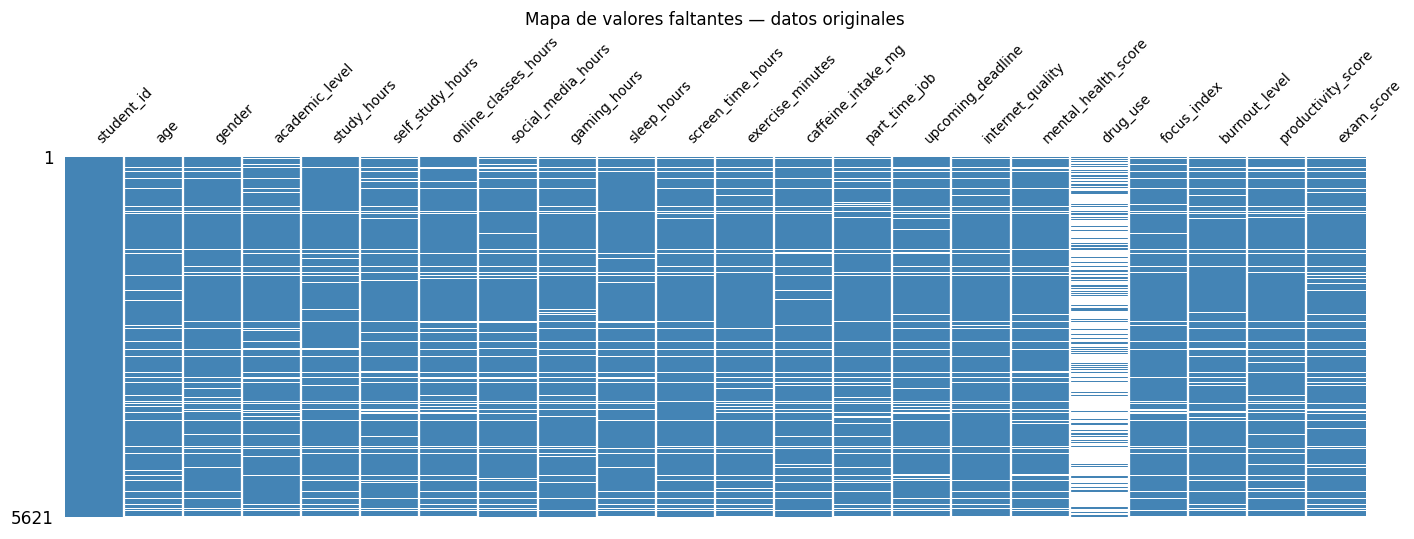

In [29]:
fig, ax = plt.subplots(figsize=(13, 5))
msno.matrix(df, ax=ax, sparkline=False, fontsize=9, color=(0.27, 0.52, 0.71))
ax.set_title('Mapa de valores faltantes — datos originales', fontsize=11)
plt.tight_layout()
plt.show()

**Observación:** `drug_use` concentra el **~73% de missings** — prácticamente inutilizable como variable explicativa. Se eliminará. El resto tiene entre 9% y 14% de valores faltantes.

### 1.3 Limpieza de variables

In [30]:
# 1. exercise_minutes: contiene strings como "120.0 min"
df['exercise_minutes'] = (df['exercise_minutes']
                          .astype(str)
                          .str.replace(' min', '', regex=False)
                          .str.strip())
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

# 2. Categóricas: espacios sobrantes y capitalización inconsistente
#    part_time_job tiene "yes"/"Yes"/"no"/"No" → unificar
df['part_time_job']  = df['part_time_job'].str.strip().str.capitalize()
df['academic_level'] = df['academic_level'].str.strip()   # "High School " → "High School"
df['gender']         = df['gender'].str.strip()

# Verificar categorías limpias
for col in ['part_time_job', 'academic_level', 'gender', 'internet_quality']:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

part_time_job: ['No', 'Yes']
academic_level: ['High School', 'Postgraduate', 'Undergraduate']
gender: ['Female', 'Male', 'Other']
internet_quality: ['Average', 'Good', 'Poor']


In [31]:
# 3. drug_use: eliminar por 73% de missings
df = df.drop(columns=['drug_use'])


In [32]:
# 4. Variable binaria rindio_examen
# primero eliminar NaN de exam_score, luego crear la binaria.
# Si se imputara exam_score antes, se fabricarían valores en la variable dependiente.
df = df.dropna(subset=['exam_score'])
df.reset_index(drop=True, inplace=True)

df['rindio_examen'] = np.where(df['exam_score'] > 1.0, 1, 0)


### 1.4 Estadísticas descriptivas

In [33]:
desc_cols = ['age','study_hours','self_study_hours','online_classes_hours',
             'social_media_hours','gaming_hours','screen_time_hours','sleep_hours',
             'exercise_minutes','caffeine_intake_mg','mental_health_score',
             'focus_index','burnout_level','productivity_score']

df[desc_cols].describe().round(2)

,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,screen_time_hours,sleep_hours,exercise_minutes,caffeine_intake_mg,mental_health_score,focus_index,burnout_level,productivity_score
count,4690.00,4742.00,4700.00,4698.00,4696.00,4710.00,4774.00,4760.00,4772.00,4740.00,4714.00,4711.00,4676.00,4749.00
mean,20.51,4.53,2.48,2.01,3.00,1.57,6.98,7.03,74.62,250.92,5.52,29.47,45.65,37.37
std,2.87,1.82,1.18,0.98,1.47,1.11,2.49,1.16,43.04,144.04,2.88,9.95,14.22,16.85
min,16.00,0.00,0.00,0.00,0.00,0.00,1.00,4.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,18.00,3.25,1.66,1.32,1.99,0.67,5.28,6.25,37.00,128.00,3.00,22.58,35.80,25.34
50%,21.00,4.53,2.48,2.01,2.98,1.49,6.96,7.03,75.00,251.00,5.50,29.47,45.72,37.01
75%,23.00,5.76,3.29,2.68,4.03,2.35,8.71,7.82,112.00,375.00,8.00,36.27,55.38,49.24
max,25.00,11.84,7.41,6.00,8.28,5.64,15.30,10.00,149.00,499.00,10.00,63.48,97.58,98.02


In [34]:
# Categóricas
for col in ['gender','academic_level','part_time_job','internet_quality']:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


gender:
gender
Male      2094
Female    2052
Other      628
NaN        138
Name: count, dtype: int64

academic_level:
academic_level
Postgraduate     1609
High School      1584
Undergraduate    1555
NaN               164
Name: count, dtype: int64

part_time_job:
part_time_job
No     2340
Yes    2332
NaN     240
Name: count, dtype: int64

internet_quality:
internet_quality
Good       1651
Average    1578
Poor       1557
NaN         126
Name: count, dtype: int64


### 1.5 Distribuciones y detección de outliers

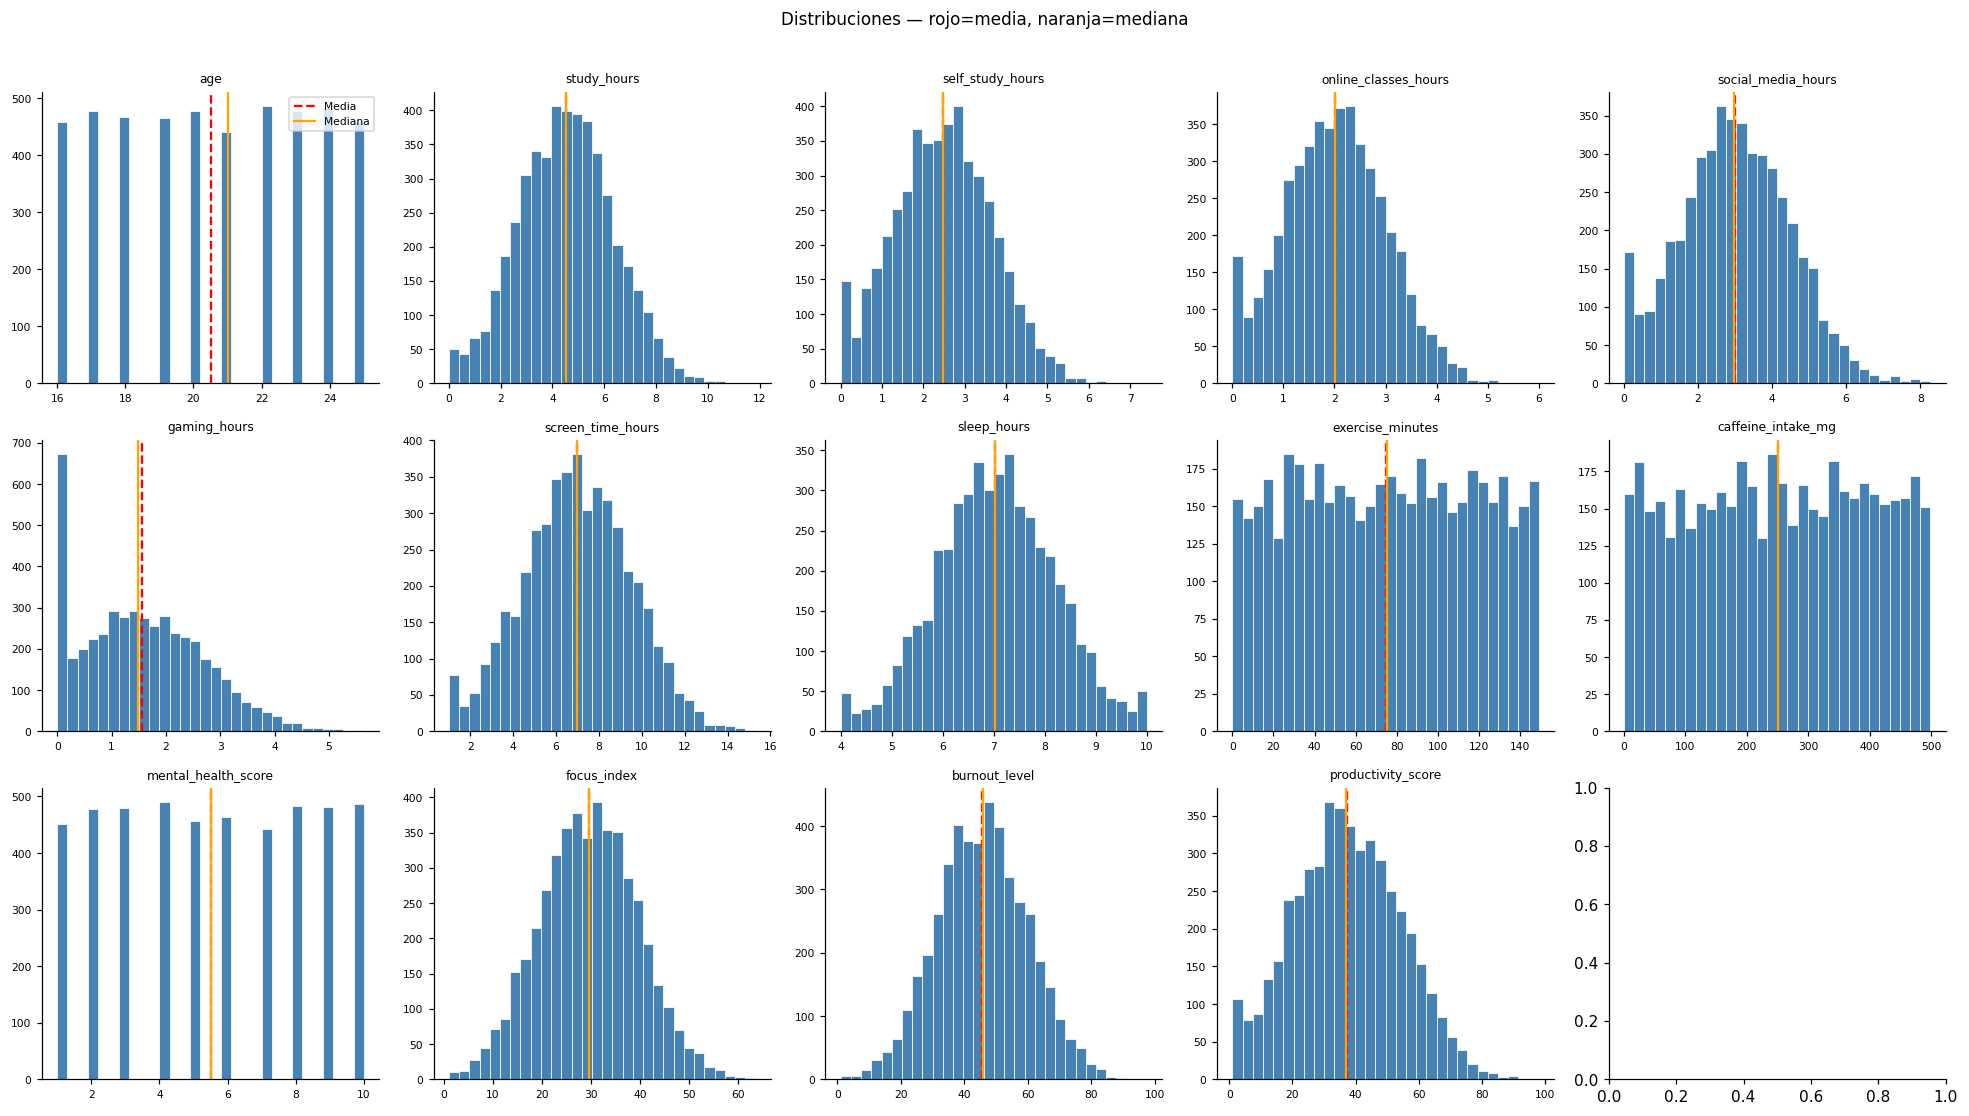

In [35]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(desc_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue',
                 edgecolor='white', linewidth=0.5)
    axes[i].axvline(df[col].mean(),   color='red',    lw=1.5, ls='--', label='Media')
    axes[i].axvline(df[col].median(), color='orange', lw=1.5, ls='-',  label='Mediana')
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

axes[0].legend(fontsize=7)
plt.suptitle('Distribuciones — rojo=media, naranja=mediana', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 1.6 Imputación de valores faltantes

Tras la limpieza, los missings restantes oscilan entre **3% y 5%** — porcentaje bajo que permite imputar sin introducir sesgo relevante.

**Criterio de imputación:**
- **Media** → variables con distribución aproximadamente simétrica.
- **Mediana** → variables asimétricas o con outliers que distorsionan la media.
- **Moda** → variables categóricas y la binaria `upcoming_deadline`.

In [36]:
# Numéricas con media (distribución simétrica)
cols_media = ['age', 'self_study_hours', 'online_classes_hours',
              'sleep_hours', 'screen_time_hours', 
              'burnout_level', 'mental_health_score', 'productivity_score',
              'caffeine_intake_mg', 'exercise_minutes']

for col in cols_media:
    valor = df[col].mean()
    df[col] = df[col].fillna(round(valor, 2))
    print(f"  {col:<30} imputado con media = {valor:.2f}")

  age                            imputado con media = 20.51
  self_study_hours               imputado con media = 2.48
  online_classes_hours           imputado con media = 2.01
  sleep_hours                    imputado con media = 7.03
  screen_time_hours              imputado con media = 6.98
  burnout_level                  imputado con media = 45.65
  mental_health_score            imputado con media = 5.52
  productivity_score             imputado con media = 37.37
  caffeine_intake_mg             imputado con media = 250.92
  exercise_minutes               imputado con media = 74.62


In [37]:
# Numéricas con mediana (distribución asimétrica / outliers) 
cols_mediana = [ 'study_hours','social_media_hours',
                 'gaming_hours', 'focus_index'] 

for col in cols_mediana:
    valor = df[col].median()
    df[col] = df[col].fillna(valor)
    print(f"  {col:<30} imputado con mediana = {valor:.2f}")

  study_hours                    imputado con mediana = 4.53
  social_media_hours             imputado con mediana = 2.98
  gaming_hours                   imputado con mediana = 1.49
  focus_index                    imputado con mediana = 29.47


In [38]:
# Binaria con moda
val = df['upcoming_deadline'].mode()[0]
df['upcoming_deadline'] = df['upcoming_deadline'].fillna(val)
print(f"  {'upcoming_deadline':<30} moda     = {int(val)}")

# Categóricas con moda
for col in ['gender','academic_level','part_time_job','internet_quality']:
    val = df[col].mode()[0]
    df[col] = df[col].fillna(val)
    print(f"  {col:<30} moda     = '{val}'"  )

  upcoming_deadline              moda     = 1
  gender                         moda     = 'Male'
  academic_level                 moda     = 'Postgraduate'
  part_time_job                  moda     = 'No'
  internet_quality               moda     = 'Good'


### 1.7 Matriz de correlaciones

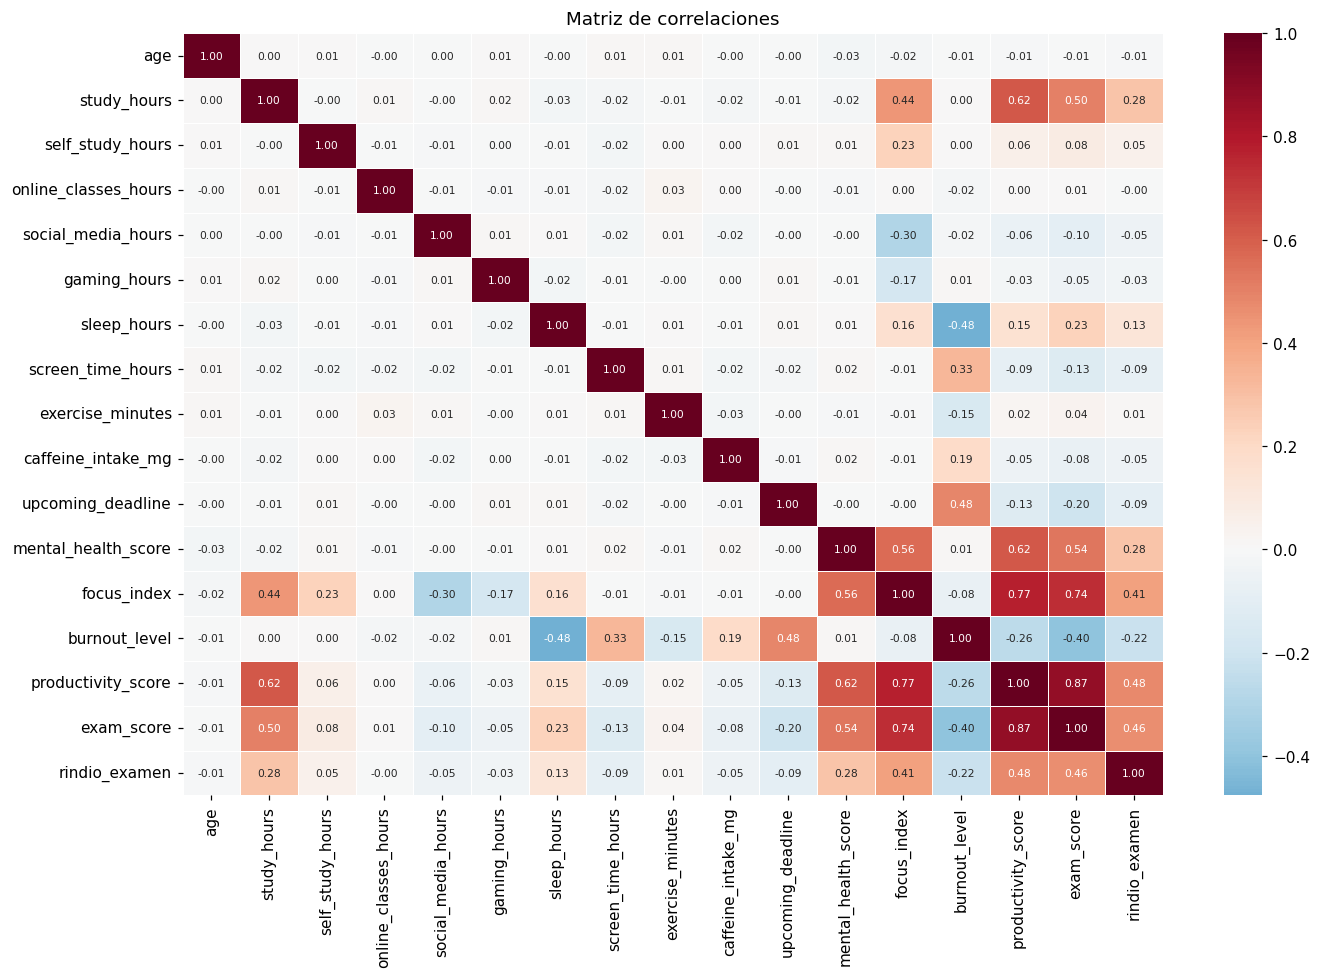

In [39]:
plt.figure(figsize=(13, 9))
cols_corr = df.select_dtypes(include=[np.number]).drop(columns=['student_id'])
sns.heatmap(cols_corr.corr(), annot=True, fmt=".2f", cmap='RdBu_r',
            center=0, linewidths=0.4, annot_kws={'size':7})
plt.title('Matriz de correlaciones', fontsize=12)
plt.tight_layout()
plt.show()

**Observación:** `focus_index`, `burnout_level` y `productivity_score` muestran correlaciones notables con `rindio_examen`. `screen_time_hours` está altamente correlacionado con otras variables de tiempo, por lo que se excluirá de los modelos.


## Pregunta 2: Modelo de Probabilidad Lineal (MCO)

El Modelo de Probabilidad Lineal (MPL) estima por MCO una variable dependiente binaria.
Los coeficientes se interpretan directamente como efectos marginales en puntos porcentuales sobre la probabilidad de rendir el examen.

### 2.1 Selección de variables

Basado en la matriz de correlación, se seleccionaron predictores académicos y psicológicos (study_hours, focus_index, burnout_level, mental_health_score) controlando por la situación laboral (part_time_job).

Además, se introdujo una variable de interacción (study_hours:burnout_level) 
para evaluar si el efecto de las horas de estudio sobre la probabilidad de rendir
 el examen depende del nivel de agotamiento del alumno.

### 2.2 Estimación

In [40]:
formula_modelos = 'rindio_examen ~ study_hours + focus_index + burnout_level + mental_health_score + C(part_time_job) + study_hours:burnout_level'
#Modelo de Probabilidad Lineal (MCO / OLS)
modelo_ols = smf.ols(formula_modelos, data=df).fit(cov_type='HC1')
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     131.9
Date:               mié, 22 abr. 2026   Prob (F-statistic):          2.67e-155
Time:                        15:16:46   Log-Likelihood:                -83.255
No. Observations:                4912   AIC:                             180.5
Df Residuals:                    4905   BIC:                             226.0
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### 2.3 Interpretación del modelo 

Interpretación de Efectos Directos 

Para las variables que no forman parte de la interacción, la interpretación es directa:

Focus Index: Es estadísticamente significativo al 1% ($p = 0.000$). Por cada punto adicional en el índice de concentración, la probabilidad base de rendir el examen aumenta en 0.63 puntos porcentuales.

Mental Health Score: Presenta un impacto altamente significativo ($p = 0.000$). Mejorar en un punto la salud mental autoreportada incrementa la probabilidad de asistencia en 1.72 puntos porcentuales.

Part-time Job: Con un valor $p = 0.102$ ($> 0.05$), esta variable no es estadísticamente significativa. Esto sugiere que la decisión de rendir o ausentarse está anclada principalmente a factores académicos y psicológicos, y no a las restricciones de tiempo que impone un trabajo de medio tiempo.

 Interpretación del Efecto de Interacción (Estudio y Agotamiento)
 
 Debido a la inclusión del término interactuado, los coeficientes de study_hours ($-0.0484$) y burnout_level ($-0.0118$) no deben interpretarse de forma aislada. El coeficiente de la interacción es positivo y altamente significativo ($+0.0017, p = 0.000$), lo que indica que el efecto marginal de las horas de estudio depende del nivel de agotamiento.
 
 El efecto marginal de las horas de estudio sobre la probabilidad ($P$) se define por la derivada parcial:$$\frac{\partial P}{\partial study} = -0.0484 + 0.0017 \times Burnout$$Al resolver para el punto donde el efecto se vuelve positivo, encontramos un punto de inflexión en los 28.5 puntos de burnout.
 
 Bajo Burnout (< 28 pts): Estudiar horas adicionales tiene un impacto nulo o levemente negativo. El alumno se encuentra en una "zona de confianza" donde su alta probabilidad de asistir no se ve alterada por el estudio marginal.
 
 Alto Burnout (ej. 80 pts): El efecto marginal se vuelve fuertemente positivo ($\approx +8.7\%$ por cada hora extra).
 
Para un estudiante colapsado, la inversión de tiempo de estudio representa un esfuerzo tan elevado que lo "ancla" psicológicamente a presentarse al examen para no invalidar el sacrificio realizado, reduciendo la probabilidad de deserción de último minuto.

## Pregunta 3: Modelo Probit

El modelo Probit asume que la probabilidad sigue una distribución normal estándar acumulada (Φ):

$$P(Y=1 | X) = \Phi(X\beta)$$

Los coeficientes estimados **no son interpretables directamente** como efectos en probabilidad. Se calculan los **efectos marginales promedio (AME)** para su interpretación.

### 3.1 Estimación

In [41]:
modelo_probit = smf.probit(formula_modelos, data=df).fit(cov_type='HC1')
print(modelo_probit.summary())

mfx_probit = modelo_probit.get_margeff()
print(mfx_probit.summary())

Optimization terminated successfully.
         Current function value: 0.148416
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4912
Model:                         Probit   Df Residuals:                     4905
Method:                           MLE   Df Model:                            6
Date:               mié, 22 abr. 2026   Pseudo R-squ.:                  0.5071
Time:                        15:16:46   Log-Likelihood:                -729.02
converged:                       True   LL-Null:                       -1478.9
Covariance Type:                  HC1   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.1364      0.363     -0.376      0.707      -0.

### 3.2 Interpretación

study_hours: Al no ser significativa la interacción, observamos su efecto directo. En promedio, por cada hora adicional de estudio, la probabilidad de que el alumno rinda el examen aumenta en 3.10 puntos porcentuales ($p = 0.000$).

mental_health_score: Sigue siendo un factor determinante. Un aumento de un punto en este índice eleva la probabilidad de presentarse al examen, en promedio, en 2.03 puntos porcentuales ($p = 0.000$).

focus_index: Aumenta la probabilidad de rendir el examen, en promedio, en 0.62 puntos porcentuales por cada punto adicional ($p = 0.000$).

burnout_level: Actúa como el principal factor de deserción. Por cada punto que aumenta el nivel de burnout, la probabilidad de rendir el examen disminuye en promedio 0.45 puntos porcentuales ($p = 0.000$).

part_time_job: La variable categórica se mantiene robustamente no significativa ($p = 0.895$), confirmando nuevamente que las obligaciones laborales externas no alteran de forma sistemática la probabilidad de asistencia al examen.

## Pregunta 4: Modelo Logit

El modelo Logit asume que la probabilidad sigue una distribución logística:

$$P(Y=1 | X) = \frac{e^{X\beta}}{1 + e^{X\beta}}$$


### 4.1 Estimación

In [42]:
modelo_logit = smf.logit(formula_modelos, data=df).fit()
print(modelo_logit.summary())

mfx_logit = modelo_logit.get_margeff()
print(mfx_logit.summary())


Optimization terminated successfully.
         Current function value: 0.147881
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4912
Model:                          Logit   Df Residuals:                     4905
Method:                           MLE   Df Model:                            6
Date:               mié, 22 abr. 2026   Pseudo R-squ.:                  0.5088
Time:                        15:16:46   Log-Likelihood:                -726.39
converged:                       True   LL-Null:                       -1478.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.6752      0.662     -1.019      0.308      -1.

### 4.2 Interpretación

study_hours: El efecto directo es altamente significativo. En promedio, cada hora extra de estudio eleva la probabilidad de rendir el examen en 3.56 puntos porcentuales ($p = 0.000$).

mental_health_score: Un aumento de un punto mejora la probabilidad de asistencia en 2.06 puntos porcentuales, en promedio ($p = 0.000$).

focus_index: Su efecto se mantiene estable e idéntico al Probit, sumando 0.62 puntos porcentuales de probabilidad por cada punto extra ($p = 0.000$).

burnout_level: Reduce la probabilidad de asistencia en promedio 0.42 puntos porcentuales por cada punto adicional de estrés ($p = 0.000$).

part_time_job: La variable se mantiene no significativa ($p = 0.968$), validando que en esta muestra el ámbito laboral externo no determina el presentismo al examen.

## Pregunta 5:Análisis Comparativo y Conclusiones

1. Comparación de Resultados (MCO, Probit y Logit)

Al observar los tres modelos, se evidencia una consistencia fundamental en la dirección y significancia de los principales determinantes. Los Efectos Marginales Promedio (dy/dx) de los modelos Probit (3.10%) y Logit (3.56%) para las horas de estudio son sumamente cercanos al coeficiente del MCO, lo que valida la robustez de los resultados. 

2. Diferencias en la interacción

La diferencia fundamental es que la interacción study_hours:burnout_level es significativa en el MCO, pero estadísticamente nula en el Probit y Logit. Los modelos no lineales (Probit/Logit) incorporan heterogeidad en los efectos marginales de manera implícita a través de su función de enlace no lineal. En el MCO, que es lineal, la interacción explícita es la única forma de capturar esa variación — de ahí que aparezca significativa solo en ese modelo.

3. Elección del Modelo Adecuado

El modelo más adecuado para esta investigación es el Modelo Probit:

Rango Lógico: Restringe las predicciones estrictamente al intervalo $[0, 1]$, corrigiendo el defecto del MCO (que arrojó un intercepto irreal de $1.04$).

Asume de forma natural que el efecto de una hora extra de estudio no es siempre igual, sino que depende de qué tan cerca esté el alumno de su límite de agotamiento 


4. Variables Robustas a la Especificación

Las variables que demostraron ser completamente robustas son:

study_hours (+): Principal impulsor académico de la asistencia.

mental_health_score (+): Condición psicológica vital para el presentismo.

focus_index (+): Predictor estable de compromiso.

burnout_level (-): Principal factor detractor y de deserción.

part_time_job (No significativa): Se confirmó de manera unánime que el trabajo de medio tiempo no afecta estructuralmente la decisión de rendir 
el examen en esta muestra.

In [48]:
# Tabla comparativa de efectos marginales en los tres modelos
from statsmodels.iolib.summary2 import summary_col

tabla = summary_col(
    [modelo_ols, modelo_probit, modelo_logit],
    model_names=['MCO', 'Probit (coef.)', 'Logit (coef.)'],
    stars=True,
    float_format='%.4f'
)
print(tabla)


                             MCO     Probit (coef.) Logit (coef.)
-----------------------------------------------------------------
C(part_time_job)[T.Yes]   -0.0125    -0.0105        -0.0059      
                          (0.0076)   (0.0797)       (0.1458)     
Intercept                 1.0414***  -0.1364        -0.6752      
                          (0.0404)   (0.3627)       (0.6624)     
R-squared                 0.2558                                 
R-squared Adj.            0.2549                                 
burnout_level             -0.0118*** -0.0541***     -0.0955***   
                          (0.0009)   (0.0068)       (0.0131)     
focus_index               0.0063***  0.0749***      0.1408***    
                          (0.0006)   (0.0062)       (0.0111)     
mental_health_score       0.0172***  0.2462***      0.4677***    
                          (0.0017)   (0.0206)       (0.0379)     
study_hours               -0.0484*** 0.3760***      0.8066***    
         

## Pregunta 6: Modelo Poisson para Notas del Examen

### 6.1 Estimación

In [43]:
#Solo alumnos que rindieron el examen
df_rendidos = df[df['rindio_examen'] == 1].copy()

# Redondeamos la nota del examen para que sea un entero
df_rendidos['exam_score_int'] = df_rendidos['exam_score'].round().astype(int)

# Omitiremos la interacción aquí para ver el efecto directo de las horas de estudio en la nota
formula_notas = 'exam_score_int ~ study_hours + focus_index + burnout_level + mental_health_score + C(part_time_job)'

modelo_poisson = smf.poisson(formula_notas, data=df_rendidos).fit()
print(modelo_poisson.summary())

impactos = (np.exp(modelo_poisson.params) - 1) * 100
print(impactos.round(2).astype(str) + " %")

Optimization terminated successfully.
         Current function value: 3.380247
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:         exam_score_int   No. Observations:                 4473
Model:                        Poisson   Df Residuals:                     4467
Method:                           MLE   Df Model:                            5
Date:               mié, 22 abr. 2026   Pseudo R-squ.:                  0.3971
Time:                        15:16:46   Log-Likelihood:                -15120.
converged:                       True   LL-Null:                       -25079.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   2.0403      0.017    118.514      0.000       2.007   

### 6.2 Interpretación

Dado que el modelo Poisson utiliza una función de enlace logarítmica, los coeficientes base se interpretaron calculando su impacto porcentual bruto mediante la fórmula de semi-elasticidad $[(e^{\beta} - 1) \times 100]$. Todos los predictores resultaron estadísticamente significativos ($p < 0.05$).

study_hours: Es el principal impulsor del rendimiento ($p = 0.000$). Por cada hora adicional de estudio, la nota esperada del alumno aumenta un 11.26%.

mental_health_score: Tiene un impacto positivo altamente significativo ($p = 0.000$). Cada punto adicional incrementa la calificación esperada en un 7.24%.

focus_index: Aporta positivamente, un aumento de un punto mejora la nota esperada en un 2.17% ($p = 0.000$).

burnout_level: Ejerce una penalización sobre el rendimiento ($p = 0.000$). Por cada punto de aumento en el nivel de agotamiento, la calificación esperada disminuye un 1.50%.

C(part_time_job)[T.Yes]: A diferencia de los modelos de presentismo, en el rendimiento académico esta variable resulta estadísticamente significativa ($p = 0.018$). Tener un trabajo de medio tiempo disminuye la nota esperada en un 1.66%, indicando que las restricciones de tiempo y energía afectan levemente la calidad del desempeño en la prueba.

## Pregunta 7: Prueba de Sobredispersión

In [44]:
# 1. Calculamos los valores predichos por el modelo Poisson (lambda)
df_rendidos['lambda_poisson'] = modelo_poisson.predict()

# 2. Construimos la variable auxiliar
df_rendidos['aux_dispersion'] = ((df_rendidos['exam_score_int'] - df_rendidos['lambda_poisson'])**2 - df_rendidos['exam_score_int']) / df_rendidos['lambda_poisson']

# 3. Corremos una regresión auxiliar 
modelo_dispersion = smf.ols('aux_dispersion ~ lambda_poisson - 1', data=df_rendidos).fit()

# Resultados
print(modelo_dispersion.summary().tables[1])
print(f"\n P-value del test: {modelo_dispersion.pvalues.iloc[0]:.4e}")
print(f" Valor óptimo de Alpha: {modelo_dispersion.params.iloc[0]:.4f}")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
lambda_poisson     0.0343      0.002     17.685      0.000       0.030       0.038

 P-value del test: 1.0565e-67
 Valor óptimo de Alpha: 0.0343


**Conclusión:** El $\hat{\alpha}$ positivo y el p-value prácticamente cero confirman **sobredispersión significativa**. La varianza de las notas es considerablemente mayor que su media (ya anticipado por el ratio varianza/media ≈ 6.18). El modelo Poisson está subestimando los errores estándar, produciendo inferencias poco fiables. Esto justifica el uso del modelo **Binomial Negativa** en la siguiente pregunta, que modela explícitamente la sobredispersión mediante el parámetro $\alpha$.

## Pregunta 8: Modelo Binomial Negativa

### 8.1 Estimación

In [45]:
modelo_nb = smf.negativebinomial(formula_notas, data=df_rendidos).fit()
 
print("=== RESULTADOS MODELO BINOMIAL NEGATIVA ===")
print(modelo_nb.summary())



 #Calculamos el impacto porcentual bruto
print("=== IMPACTO PORCENTUAL SOBRE LA NOTA ESPERADA (%) ===")
impactos_nb = (np.exp(modelo_nb.params) - 1) * 100
print(impactos_nb.round(2).astype(str) + " %")

Optimization terminated successfully.
         Current function value: 3.256337
         Iterations: 19
         Function evaluations: 38
         Gradient evaluations: 29
=== RESULTADOS MODELO BINOMIAL NEGATIVA ===
                     NegativeBinomial Regression Results                      
Dep. Variable:         exam_score_int   No. Observations:                 4473
Model:               NegativeBinomial   Df Residuals:                     4467
Method:                           MLE   Df Model:                            5
Date:               mié, 22 abr. 2026   Pseudo R-squ.:                  0.1472
Time:                        15:16:46   Log-Likelihood:                -14566.
converged:                       True   LL-Null:                       -17081.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

### 8.2 Interpretación

El modelo BN estimó un parámetro de dispersión de $\alpha = 0.0500$, el cual resultó altamente significativo ($p = 0.000$). Esto ratifica que la varianza de las notas es mayor que su media, justificando la elección de este modelo predictivo.

Evaluando el impacto porcentual $[(e^{\beta} - 1) \times 100]$ con los errores estándar corregidos:

study_hours: Se mantiene como el factor de mayor impacto positivo ($p = 0.000$). Por cada hora adicional estudiada, la nota esperada aumenta en un 12.25%.

mental_health_score: Su efecto es altamente significativo ($p = 0.000$). Cada punto adicional mejora el rendimiento esperado en un 7.56%.

focus_index: Aumenta la calificación esperada de forma constante en 2.39% por cada punto extra ($p = 0.000$).

burnout_level: Es la única variable continua con efecto negativo ($p = 0.000$). Disminuye la nota esperada en 1.63% por cada punto de estrés adicional.

El hallazgo más relevante al corregir el modelo es el cambio en la variable categórica part_time_job. En el modelo Poisson esta variable parecía significativa; sin embargo, en la especificación BN pierde significancia estadística al nivel del 5% ($p = 0.076$). Esto demuestra que, al corregir los márgenes de error artificialmente pequeños del Poisson, comprobamos que tener un trabajo de medio tiempo en realidad no tiene un impacto negativo robusto sobre la nota final del examen.

## Pregunta 9:Análisis Comparativo y Conclusiones

In [49]:
# Tabla comparativa Poisson vs Binomial Negativa
from statsmodels.iolib.summary2 import summary_col

tabla_conteo = summary_col(
    [modelo_poisson, modelo_nb],
    model_names=['Poisson', 'Binomial Negativa'],
    stars=True,
    float_format='%.4f',
    info_dict={'Log-Likelihood': lambda m: f'{m.llf:.1f}'}
)
print(tabla_conteo)


                         Poisson   Binomial Negativa
----------------------------------------------------
C(part_time_job)[T.Yes] -0.0167**  -0.0183*         
                        (0.0071)   (0.0103)         
Intercept               2.0403***  1.9646***        
                        (0.0172)   (0.0251)         
alpha                              0.0500***        
                                   (0.0024)         
burnout_level           -0.0151*** -0.0164***       
                        (0.0003)   (0.0004)         
focus_index             0.0215***  0.0236***        
                        (0.0005)   (0.0007)         
mental_health_score     0.0699***  0.0729***        
                        (0.0015)   (0.0022)         
study_hours             0.1067***  0.1156***        
                        (0.0022)   (0.0033)         
Log-Likelihood          -15119.8   -14565.6         
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


Revisando los modelos para predecir la nota, al principio el modelo Poisson nos daba a entender que casi todo importaba, mostrando incluso un efecto negativo si el alumno tenía un trabajo part-time. Sin embargo, el test de dispersión de la arrojó un p-value prácticamente de cero, señalando que los supuestos del poisson no se cumplen


El cambio más notorio es en la variable del trabajo a medio tiempo (part_time_job). En el Poisson salía significativa, pero en el modelo BN dejó de serlo. Esto pasa por una limitación técnica del modelo Poisson: asume que la media y la varianza de las notas son iguales. Como nuestros datos reales tienen mucha sobredispersión, el Poisson estaba dando márgenes de error demasiado pequeños, mostrándonos un "falso positivo" con el tema del trabajo.

El modelo más adecuado:

Me quedo con el modelo Binomial Negativo. Ya que en el test de sobredispersión y el parámetro alfa que calculó el modelo BN (alfa = 0.0500, p = 0.000) nos confirman que hay sobredispersión en las notas. Por lo tanto, el modelo Poisson se queda corto en sus supuestos y el BN es el único que nos entrega p-values de los que realmente nos podemos fiar.

Variables robustas:

Viendo qué sobrevive al cambio de modelo, las variables que realmente son robustas y explican el rendimiento de los alumnos son:

Horas de estudio (+): Es el factor que más ayuda a subir la nota.

Salud mental (+): Super importante para el rendimiento.

Índice de concentración (+): Suma constantemente a la calificación.

Nivel de burnout (-): Es el principal factor que drena y baja la nota final.

Se descarta la idea de que tener un trabajo part-time afecte estructuralmente el rendimiento. Solo parecía importar por el error del primer modelo